# DREAMS Snapshot Hosting Capacity

Building on the introduction notebook, this notebook will show:

* How to configure and run a snapshot `stepped hosting capacity` simulation looking at the impact of EV charging placed only on the C phase of the demo model.

* Basic plots will be used to demonstrate the impact of this and overloading elements will be identified.

* a basic statistic comparison approach will be shown

* and violations from different simulation steps will be compared.

Unlike more standard hosting capacity analysis, which returns only the maximum amount of an asset that may be added to a location until a system violation occurs, the stepped hosting capacity of DREAMS allows system states with violations so that the severity of impacts can be assesed and mitigation approaches tested.

It is worth noting that DREAMS also has nodal hosting capacity functionality that will be shown in a later notebook.

# Load Feeder
This is a typical way to load dreams and define some paths for the model and any outputs, which is described more in the introduction notebook.

In [34]:
import dreams

from pathlib import Path
import os

In [35]:
model_dir = Path(r'models') / r'sfo_p1udt1469'

output_dir = model_dir / 'temp_outputs'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [36]:
feeder = dreams.Feeder(model_dir/'Main.dss', name='sfo_p1udt1469')


Initial plots and statistic collection for will be useful to compare the effects of the expected scenario simulation.

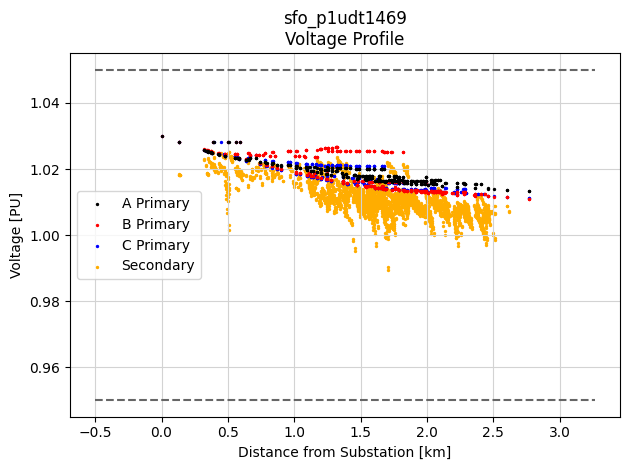

In [37]:
profile_fig_0, profile_ax_0 = feeder.plot()

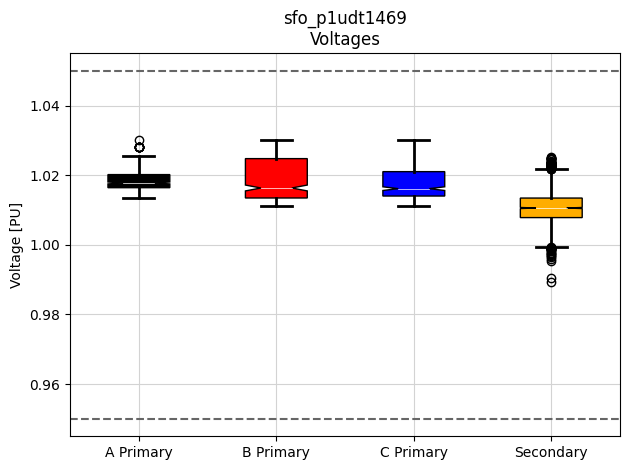

In [38]:
box_fig_0, box_ax_0 = feeder.plot(kind='box')

In [39]:
stats_0 = feeder.stats

In [40]:
stats_0['init_kw']

6144.109120674652

In [41]:
stats_0['n_cust']

2120

# Create Stepped Hosting Capacity Scenario 

A simple stepped hosting capacity scenario is created below using 5 steps and 10 simulations.


This means that the expectation is to add 5 different levels of increasing EV loading 10 times.

The difference between each simulation will be the random number seed used to populate the demand across the available system locations.

This is meant to account for some uncertainty of where such loads may be connected.


In [42]:
scenario = dreams.hc.Scenario(
    name='Snapshot Distributed Load',
    feeder=feeder,
    n_simulations=10,  # This is how many different random sets of allocations to run
    n_steps=5,  # this is how many steps from 0-full allocation each simulation takes
    #minimize_duplicates=False,  # Defaults to True, attempts to allocate elements to all available locations before stacking locations
)

## Creation of alloctaion class and element
The alloction object allows different types of elements to be added to a model in a user defined way.

Below, the number of lvl 2 EV chargers using 15 kW is estimated to increase 1% each step.

Also of note here is the `element_prepend` parameter, which can be helpful to identify to each element added to the model through this process.

In [43]:
# allocation class acts as container for  allocation elements
ev_alloc_2 = dreams.hc.Allocation(feeder, name='LVL_2_EV') 

# calculate number of level 2 chargers to add per scenario step
n_lvl_2 = int(feeder.stats['n_cust'] * .01)

# create load allocation element
lvl2_ev = dreams.hc.LoadAllocationElement(
    'LVL_2_EV',
    element_prepend='EV_LVL_2_',
    element_kw=15,
    element_kvar=0,
    n_elements=n_lvl_2
)

# add load elemnt to allocation
ev_alloc_2.add_allocation_element(lvl2_ev)

# display contents of ev_alloc_2 rules
ev_alloc_2.rules

{'element': {'LVL_2_EV': Load Element Name: LVL_2_EV // 0 elements allocated // Total: 0 kw 0 kvar},
 'location': {},
 'capacity': {},
 'size': {},
 'control': {},
 'shape': {}}

## definition of allocation location rule
Each allocation can also follow various rules for placement.

This example ensures that the location for interconnection is a transformer, 
and that the bus2 phase is equal to C.

In [44]:

ev_alloc_2.add_location_rule(
    name='Secondary of C Phase Transformers',
    feeder_element_class='transformers',
    element_attribute='bus1_phase',
    comparison_operation='==',
    comparison_value='C',
    bus1_attribute='bus2',
    )

scenario.add_allocation(ev_alloc_2)

It's worth noting that standard pandas equalities are used for this comparison.


Below showws the total number of such locations found in the demo feeder.

In [45]:
(feeder.transformers['bus1_phase'] == 'C').sum()

62

# writing of scenario steps and running of simulation
DREAMS can write the steps, or openDSS redirects, used to modify the original feeder to the simulated state.

this is valuable to recreate or analyze generated scenarios after simulation.

These steps are written to a folder located with the model.

In [46]:
scenario.write_steps()  

The run method of the scenario class will execute the simulation.
Results are stored in the object for later analysis.

In [47]:
scenario.run()

Started Snapshot Simulation
Completed seed: 0
Completed seed: 3264
Completed seed: 9225
Completed seed: 2732
Completed seed: 5874
Completed seed: 7891
Completed seed: 9845
Completed seed: 4373
Completed seed: 6744
Completed seed: 4859
Finished all Seeds


# Result plots
The scenario object stores results according to seed and then step.

Below is the load allocation showing the total load added, and the number of loads added at each step (cumulative).

Similar alloction plots are available for other alloctaions, though for this demo, only load was applied.

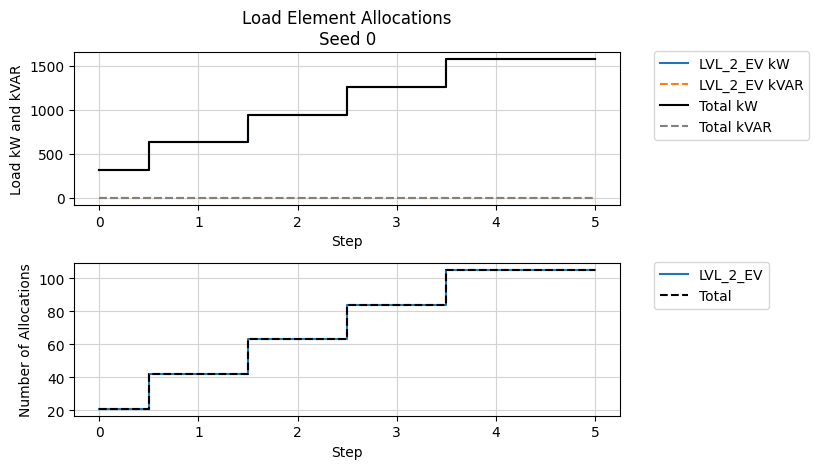

(<Figure size 640x480 with 2 Axes>,
 [<Axes: title={'center': 'Load Element Allocations\nSeed 0'}, xlabel='Step', ylabel='Load kW and kVAR'>,
  <Axes: xlabel='Step', ylabel='Number of Allocations'>])

In [48]:
scenario.seed_results[0].plot(kind='load_allocation')


The default plot of a snapshot simulation is the voltage profile.
One can see that as the steps increase, more load is added, and the voltage spread increases.

It is worth noting that the levels presented are system-wide voltages.

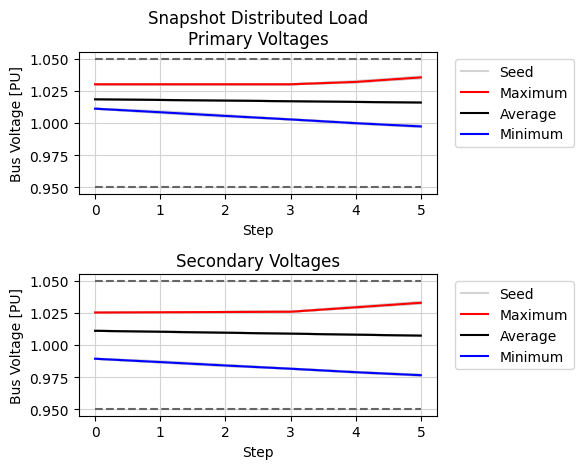

(<Figure size 640x480 with 2 Axes>,
 [<Axes: title={'center': 'Snapshot Distributed Load\nPrimary Voltages'}, xlabel='Step', ylabel='Bus Voltage [PU]'>,
  <Axes: title={'center': 'Secondary Voltages'}, xlabel='Step', ylabel='Bus Voltage [PU]'>])

In [49]:
scenario.results.plot()

As a reminder, the original voltage profile is shown below

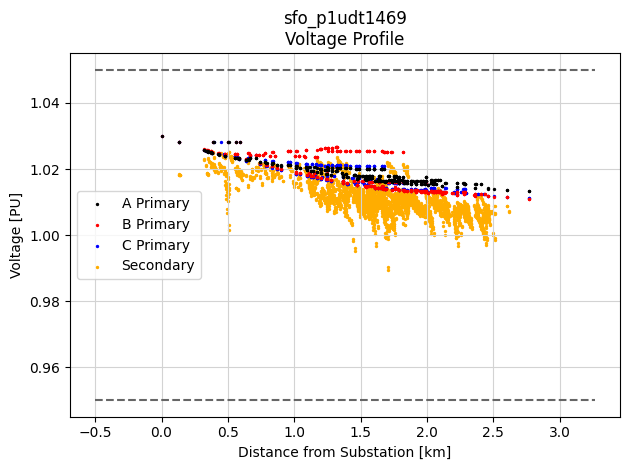

In [50]:
profile_fig_0

After a simulation has been run, the `feeder.plot()` method is called again, which will display the same plot, but from the most recent feeder state.

Which happends to be the last step from the last seed of the hosting capacity scenario.

It is easy to see that the B and C phase are much lower than the A phase, and the general voltage spread is much larger.

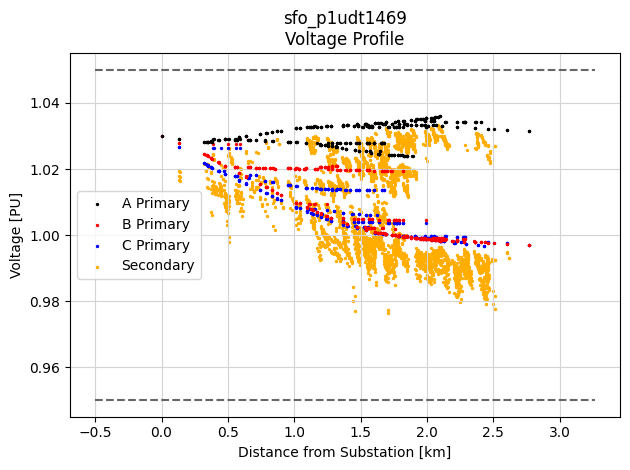

In [51]:
profile_fig_1, profile_ax_1 = feeder.plot()

A similar process could be completed using the box plots where the original voltage boxes are shown below

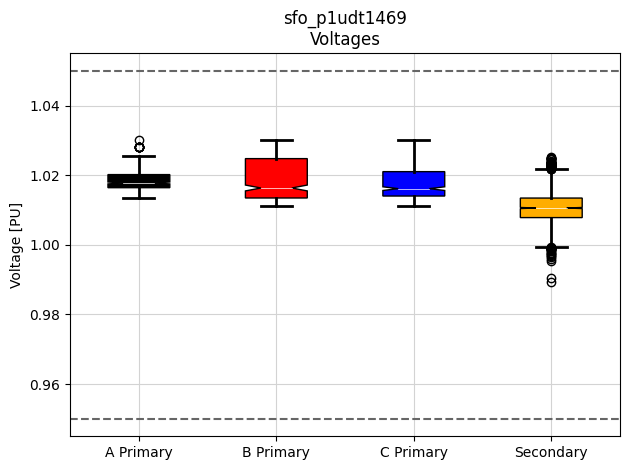

In [52]:
box_fig_0

And the post simulation voltage boxes (reprentative of the last step from the last seed) are simply created from the feeder object.

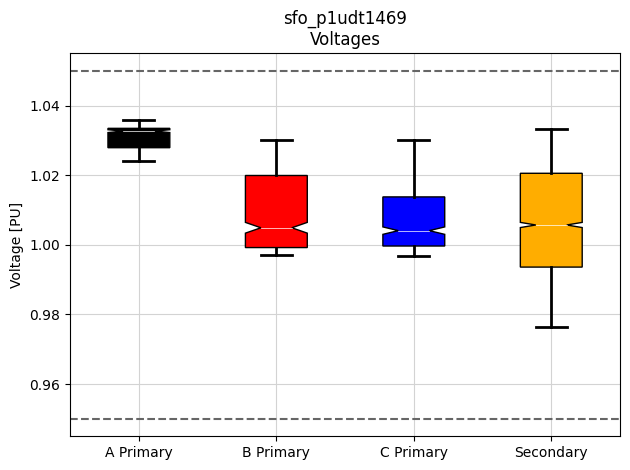

In [53]:
box_fig_1, box_ax_1 = feeder.plot(kind='box')

Another useful type of plot is the `plotly` plot that allows for a more interactive experience typical of plotly plots.

In [54]:
fig = feeder.plot(kind='plotly')

## additional simulation plots
Transformer and line loading plots are also available from the scenario object after it has been run.

The transformer loading plot more clearly shows the impact of the different seeds - where due to the random placement, different amounts of transformer loading occurs (as shown with the various grey lines).

The maximum presented is actualy the average maximum from all seeds.

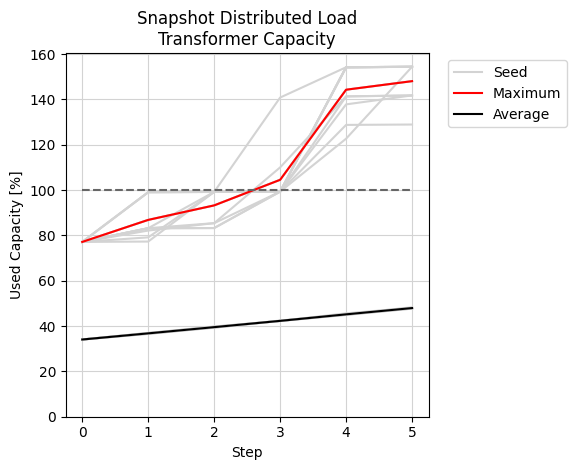

(<Figure size 640x480 with 1 Axes>,
 [<Axes: title={'center': 'Snapshot Distributed Load\nTransformer Capacity'}, xlabel='Step', ylabel='Used Capacity [%]'>])

In [55]:
scenario.results.plot(kind='transformer')

Additionally, the line capacity plots show that only the primary system is impacted by increased demand.

This is indicative of the load being placed directly on the low side of the transformer.

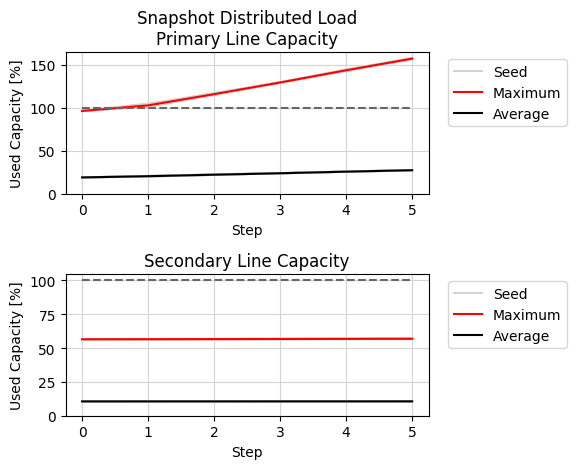

(<Figure size 640x480 with 2 Axes>,
 [<Axes: title={'center': 'Snapshot Distributed Load\nPrimary Line Capacity'}, xlabel='Step', ylabel='Used Capacity [%]'>,
  <Axes: title={'center': 'Secondary Line Capacity'}, xlabel='Step', ylabel='Used Capacity [%]'>])

In [56]:
scenario.results.plot(kind='line')

While plot calls will typically use the most recent feeder state, as of this writing, the stored dataframes need to be updated to reflect the added loads.

As shown below, the call to the `loads` dataframe does not include any of the additional loads until the update method is called.

In [57]:
feeder.loads.tail(5)

,phases,kv,kw,kvar,pf,conn,bus1,model,status,short_bus1,bus1_nodes,bus1_phase,primary
name,,,,,,,,,,,,,
load_p1ulv289_2,1,0.12,1.601029,0.412846,0.968325,wye,p1ulv289.2,1,Variable,p1ulv289,2,B,False
load_p1ulv598_1,1,0.12,7.905350,0.743145,0.995611,wye,p1ulv598.1,1,Variable,p1ulv598,1,A,False
load_p1ulv598_2,1,0.12,7.905350,0.743145,0.995611,wye,p1ulv598.2,1,Variable,p1ulv598,2,B,False
load_p1ulv1670_1,1,0.12,7.905350,0.743145,0.995611,wye,p1ulv1670.1,1,Variable,p1ulv1670,1,A,False
load_p1ulv1670_2,1,0.12,7.905350,0.743145,0.995611,wye,p1ulv1670.2,1,Variable,p1ulv1670,2,B,False


In [58]:
feeder.update()
feeder.loads.tail(5)

,phases,kv,kw,kvar,pf,conn,bus1,model,status,short_bus1,bus1_nodes,bus1_phase,primary
name,,,,,,,,,,,,,
ev_lvl_2_101_p1udt295lv,1,0.120089,15.0,0.0,1.0,wye,p1udt295lv.1.0,1,Variable,p1udt295lv,1,A,False
ev_lvl_2_102_p1udt419lv,1,0.120089,15.0,0.0,1.0,wye,p1udt419lv.1.0,1,Variable,p1udt419lv,1,A,False
ev_lvl_2_103_p1udt240lv,1,0.120089,15.0,0.0,1.0,wye,p1udt240lv.1.0,1,Variable,p1udt240lv,1,A,False
ev_lvl_2_104_p1udt244lv,1,0.120089,15.0,0.0,1.0,wye,p1udt244lv.1.0,1,Variable,p1udt244lv,1,A,False
ev_lvl_2_105_p1udt87lv,1,0.120089,15.0,0.0,1.0,wye,p1udt87lv.1.0,1,Variable,p1udt87lv,1,A,False


## compare pre/post statistics
since the original statistics were stored, and the feeder has been recently updated,
it may be worth looking at the impact of the simulation.

This can be accomplished by creating a dataframe from the feeder stats dictionary, and then doing a simple substraction.

Note: some columns are removed as they do not have subtraction functionality.

In [59]:
stats_1 = feeder.stats


In [60]:
import pandas as pd

cols_to_drop = ['kv_levels', 'path', 'name']
stat_df = pd.DataFrame.from_dict({'original':stats_0, 'post_ev':stats_1})
stat_df.drop(cols_to_drop, inplace=True)

stat_df['ev_impact'] = stat_df['post_ev'] - stat_df['original'] 
stat_df

,original,post_ev,ev_impact
source_pu,1.03,1.03,0.0
source_kv,12.47,12.47,0.0
init_kw,6144.109121,7719.109121,1575.0
init_kvar,1610.723156,1610.723156,0.0
feeder_max_length_km,2.766513,2.766513,0.0
n_bus,2217,2217,0
n_lines,2007,2007,0
n_primary_lines,234,234,0
length_primary_lines_km,10.89886,10.89886,0.0
n_secondary_lines,1392,1392,0


NOTE: due to previous research direction, and speed of snapshot simulations, export of snapshot results has not been as deeply developed as QSTS results.

# go to step
DREAMS allows the simulation go to a specific state, essentially running the 
simulation again and stopping at a certain step.

This allows the feeder state to be more closely examined.

WARNING: using the go_to_step method will erase all previous step results.

To verify this operation feeder violations from the last step are saved, 
then comparted to the violations from step 3.

In [61]:
violations_step_5 = feeder.id_violations()
violations_step_5.keys()

dict_keys(['over_capacity', 'n_over_capacity', 'over_capacity_lines', 'n_over_capacity_lines', 'over_capacity_transformers', 'n_over_capacity_transformers', 'over_voltage', 'n_over_voltage', 'under_voltage', 'n_under_voltage', 'zero_voltage', 'n_zero_voltage', 'percent_violation_voltage', 'percent_violation_primary_voltage', 'percent_violation_secondary_voltage', 'percent_violation_xfmr_capacity', 'percent_violation_line_capacity', 'percent_violation_primary_line_capacity', 'percent_violation_secondary_line_capacity'])

In [62]:
violations_step_5['n_over_capacity']

77

In [63]:
scenario.go_to_step(step=3)

In [64]:
violations_step_3 = feeder.id_violations()
violations_step_3['n_over_capacity']

49

As one can observed, there are fewer violations in step_3 than step_5 - 
which makes sense, as there is more demand in step_5.

Additionaly, the overcapacity lines (and other objects identified in violation) can be further examined as they are also pandas dataframes.

In [65]:
violations_step_3['over_capacity_lines'].head()

,Name,Imax,%normal,%emergency,kW,kvar,NumCustomers,TotalCustomers,NumPhases,kVBase,kind,short_name,primary
0,Line.L(R:P1UDT1469-P1UHS0_1247),414.052,127.40,69.01,7272.28,1105.03,0,2183,3,7.2,Line,L(R:P1UDT1469-P1UHS0_1247),True
1,Line.L(R:P1UDT1469-P1UDT940),401.617,123.57,66.94,7021.35,1055.49,0,2165,3,7.2,Line,L(R:P1UDT1469-P1UDT940),True
2,Line.PADSWITCH(R:P1UDT940-P1UDT941)P1U_9557,401.618,123.57,66.94,6998.95,1028.38,0,2163,3,7.2,Line,PADSWITCH(R:P1UDT940-P1UDT941)P1U_9557,True
3,Line.L(R:P1UDT940-P1UDT941),401.618,108.55,66.94,6998.63,1028.07,0,2163,3,7.2,Line,L(R:P1UDT940-P1UDT941),True
4,Line.PADSWITCH(R:P1UDT940-P1UDT941)P1U_9558,401.620,108.55,66.94,6997.66,1026.86,0,2163,3,7.2,Line,PADSWITCH(R:P1UDT940-P1UDT941)P1U_9558,True


This concludes the basic snapshot stepped hosting capacity demo.